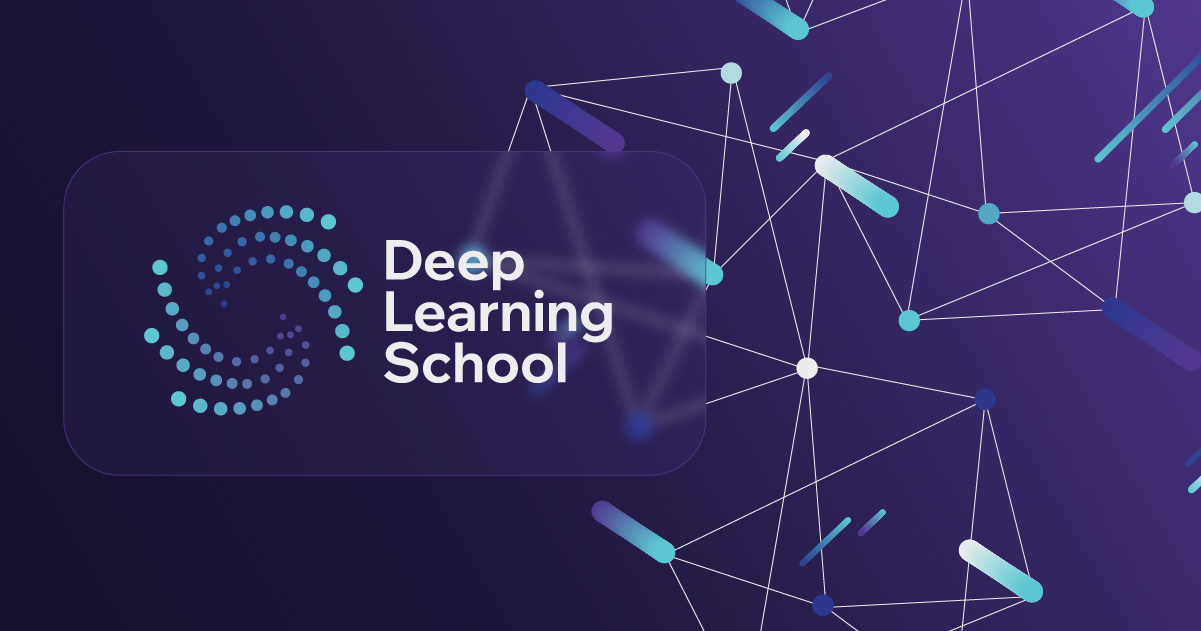


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

In [64]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [65]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [66]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [67]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [68]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [69]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,' imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [70]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'attr' in filename.lower() or 'lfw' in filename.lower():
            print(os.path.join(dirname, filename))

/kaggle/input/lfw-attributes/lfw_attributes.txt
/kaggle/input/lfw-dataset/lfw_allnames.csv
/kaggle/input/lfw-dataset/lfw_readme.csv
/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Kim_Cattrall/Kim_Cattrall_0001.jpg
/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Sebastian_Cuattrin/Sebastian_Cuattrin_0001.jpg


In [71]:
import kagglehub
import os

attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print(attrs_path)

for dirname, _, filenames in os.walk(attrs_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Using Colab cache for faster access to the 'lfw-attributes' dataset.
/kaggle/input/lfw-attributes
/kaggle/input/lfw-attributes/lfw_attributes.txt


In [72]:
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [73]:
import pandas as pd

df_attrs_check = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
print(df_attrs_check.columns.tolist())
print(df_attrs_check.head())

['#', 'person', 'imagenum', 'Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth', 'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair', 'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling', 'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash', 'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair', 'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead', 'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows', 'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose', 'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open', 'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee', 'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face', 'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man', 'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes', 'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pale Skin', "5 o' Clock Shadow", 'Strong Nose-Mouth Lines', 'Wearing Lip

In [74]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    import os
    import pandas as pd
    import numpy as np
    import imageio
    from PIL import Image

    # читаем атрибуты
    df_attrs_raw = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)

    # ВАЖНО:
    # файл атрибутов читается со сдвигом:
    # в колонке "#" лежит person,
    # в колонке "person" лежит imagenum,
    # поэтому делаем сдвиг колонок как в исходном шаблоне
    df_attrs = pd.DataFrame(
        df_attrs_raw.iloc[:, :-1].values,
        columns=df_attrs_raw.columns[1:]
    )

    df_attrs.columns = df_attrs.columns.str.strip()

    df_attrs['person'] = df_attrs['person'].astype(str)
    df_attrs['imagenum'] = df_attrs['imagenum'].astype(int)

    photo_ids = []

    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)

                # пример: Aaron_Eckhart_0001.jpg
                name_without_ext = fname[:-4]
                parts = name_without_ext.split('_')

                person_id = ' '.join(parts[:-1])
                photo_number = int(parts[-1])

                photo_ids.append({
                    'person': person_id,
                    'imagenum': photo_number,
                    'photo_path': fpath
                })

    photo_ids = pd.DataFrame(photo_ids)

    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    print("df_attrs:", df_attrs.shape)
    print("photo_ids:", photo_ids.shape)
    print("merged df:", df.shape)

    assert len(df) > 0, "После объединения получилось 0 строк. Значит person/imagenum не совпали."

    images = df['photo_path'].apply(imageio.imread)\
        .apply(lambda img: img[dy:-dy, dx:-dx])\
        .apply(lambda img: np.array(Image.fromarray(img).resize((dimx, dimy))))

    images = np.stack(images.values).astype('uint8')

    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [75]:
images, attrs = fetch_dataset()

df_attrs: (13143, 75)
photo_ids: (13233, 3)
merged df: (13143, 76)



Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [76]:
print("images shape:", images.shape)
print("attrs shape:", attrs.shape)

# Нормализуем картинки в диапазон [0, 1]
images = images.astype("float32") / 255.0

# train / val split
X_train, X_val, attrs_train, attrs_val = train_test_split(
    images,
    attrs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Переводим картинки из NHWC в NCHW:
# было (N, H, W, C), станет (N, C, H, W)
X_train_t = torch.tensor(X_train).permute(0, 3, 1, 2).float()
X_val_t = torch.tensor(X_val).permute(0, 3, 1, 2).float()

batch_size = 64

train_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t),
    batch_size=batch_size,
    shuffle=False
)

print("Train tensor:", X_train_t.shape)
print("Val tensor:", X_val_t.shape)

images shape: (13143, 45, 45, 3)
attrs shape: (13143, 73)
Train tensor: torch.Size([10514, 3, 45, 45])
Val tensor: torch.Size([2629, 3, 45, 45])


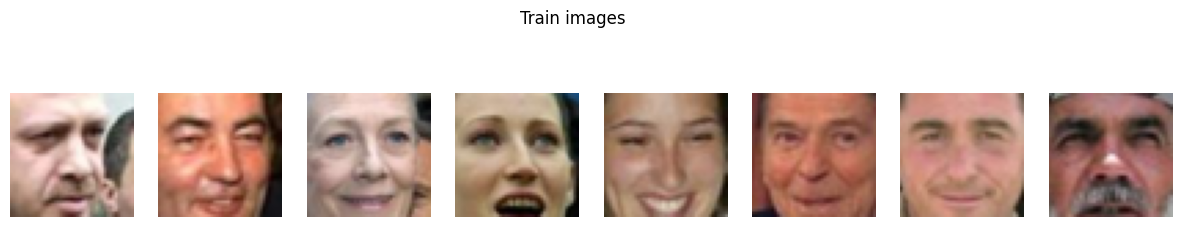

In [77]:
def show_images(images, n=8, title=None):
    plt.figure(figsize=(15, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)

        img = images[i]
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu()
            if img.ndim == 3:
                img = img.permute(1, 2, 0).numpy()
            else:
                img = img.numpy()

        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.axis("off")

    if title is not None:
        plt.suptitle(title)
    plt.show()

show_images(X_train_t, n=8, title="Train images")

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



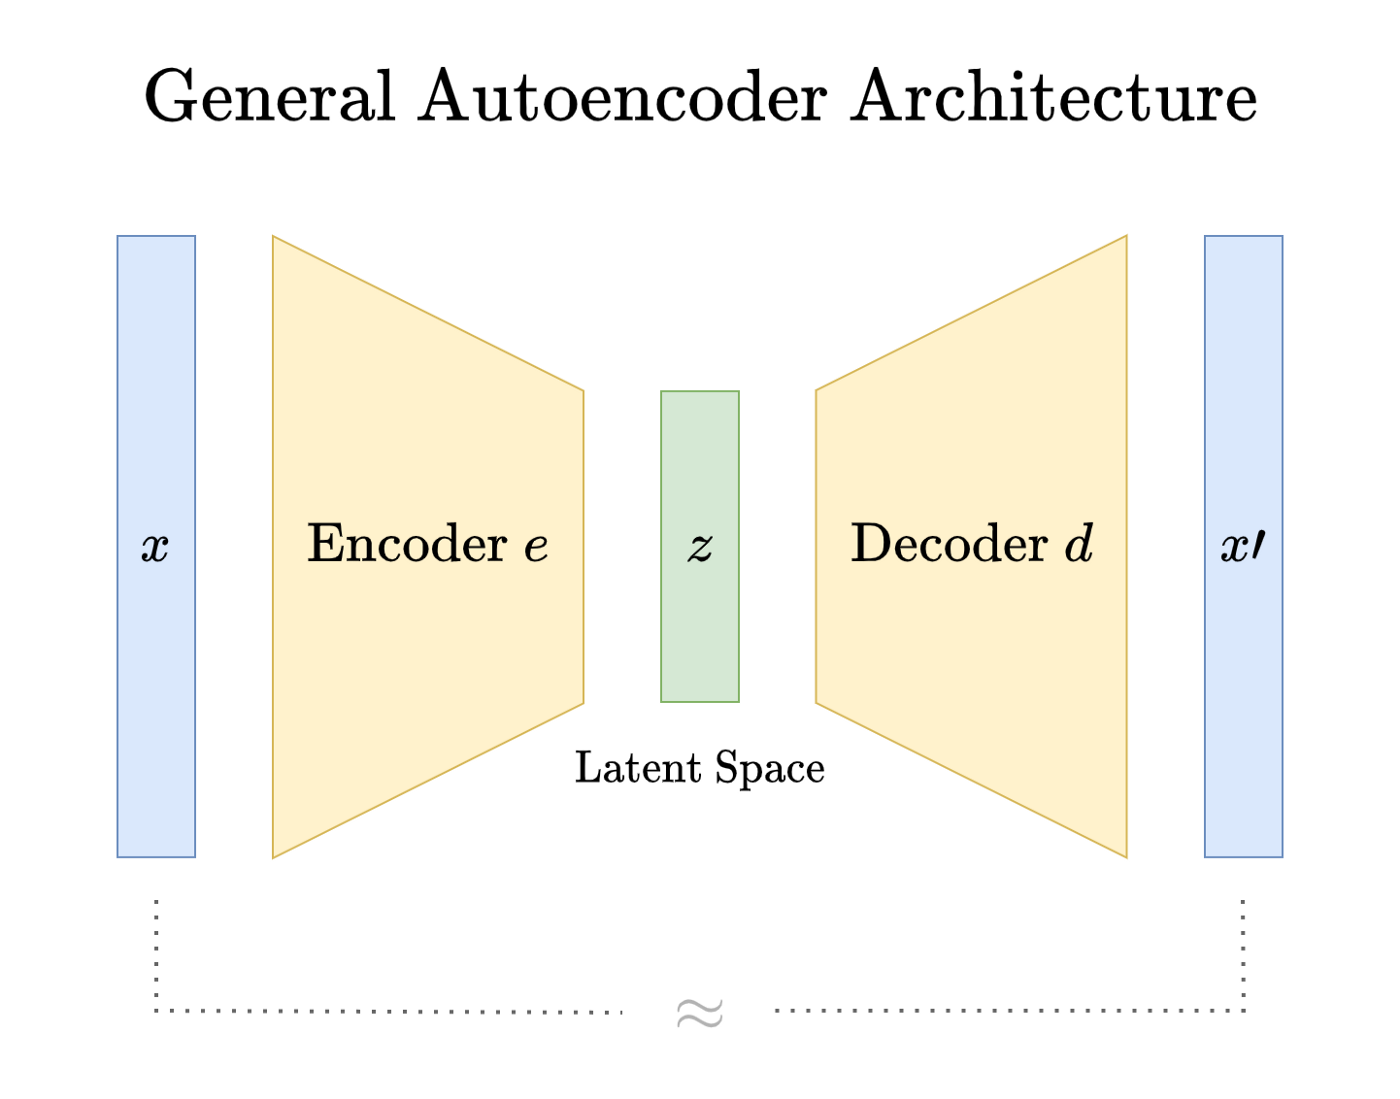

In [78]:
dim_code = 128

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [79]:
class Autoencoder(nn.Module):
    def __init__(self, dim_code=128):
        super().__init__()

        self.dim_code = dim_code

        # Картинка 3 x 45 x 45 = 6075 признаков
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 45 * 45, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, dim_code)
        )

        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3 * 45 * 45),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        reconstruction = reconstruction.view(-1, 3, 45, 45)
        return reconstruction, latent_code

In [80]:
criterion = nn.MSELoss()

autoencoder = Autoencoder(dim_code=dim_code).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [81]:
def train_autoencoder(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for batch in train_loader:
            x = batch[0].to(device)

            optimizer.zero_grad()
            reconstruction, latent_code = model(x)
            loss = criterion(reconstruction, x)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device)
                reconstruction, latent_code = model(x)
                loss = criterion(reconstruction, x)
                val_loss += loss.item() * x.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch + 1}/{epochs} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    return train_losses, val_losses


train_losses, val_losses = train_autoencoder(
    autoencoder,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=20
)

Epoch 1/20 | train loss: 0.021815 | val loss: 0.015564
Epoch 2/20 | train loss: 0.013156 | val loss: 0.012551
Epoch 3/20 | train loss: 0.011778 | val loss: 0.011435
Epoch 4/20 | train loss: 0.010880 | val loss: 0.010475
Epoch 5/20 | train loss: 0.010213 | val loss: 0.010331
Epoch 6/20 | train loss: 0.009768 | val loss: 0.009698
Epoch 7/20 | train loss: 0.009275 | val loss: 0.009272
Epoch 8/20 | train loss: 0.008774 | val loss: 0.009110
Epoch 9/20 | train loss: 0.008436 | val loss: 0.008745
Epoch 10/20 | train loss: 0.008109 | val loss: 0.008281
Epoch 11/20 | train loss: 0.007712 | val loss: 0.007745
Epoch 12/20 | train loss: 0.007385 | val loss: 0.007515
Epoch 13/20 | train loss: 0.007202 | val loss: 0.007589
Epoch 14/20 | train loss: 0.007069 | val loss: 0.007486
Epoch 15/20 | train loss: 0.006932 | val loss: 0.007145
Epoch 16/20 | train loss: 0.006719 | val loss: 0.007115
Epoch 17/20 | train loss: 0.006568 | val loss: 0.006906
Epoch 18/20 | train loss: 0.006415 | val loss: 0.006857
E

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

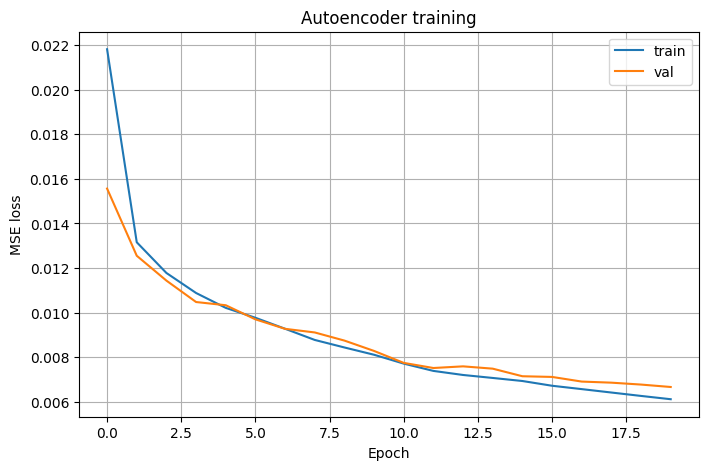

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training")
plt.legend()
plt.grid()
plt.show()

Что вы можете сказать про результат?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

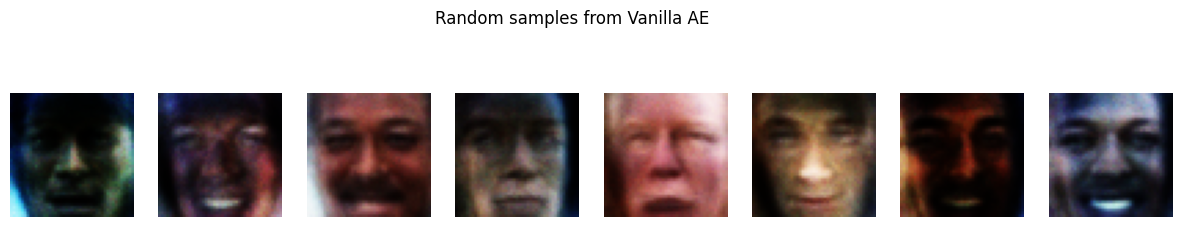

In [83]:
autoencoder.eval()

with torch.no_grad():
    z_random = torch.randn(8, dim_code).to(device)
    generated = autoencoder.decoder(z_random)
    generated = generated.view(-1, 3, 45, 45)

show_images(generated, n=8, title="Random samples from Vanilla AE")

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [84]:
print(attrs.columns.tolist())

['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth', 'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair', 'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling', 'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash', 'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair', 'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead', 'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows', 'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose', 'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open', 'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee', 'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face', 'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man', 'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes', 'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pale Skin', "5 o' Clock Shadow", 'Strong Nose-Mouth Lines', 'Wearing Lipstick', 'Flushed Face', 'Hi

In [85]:
smile_col = "Smiling"

# На всякий случай проверим
assert smile_col in attrs_train.columns, f"Колонка {smile_col} не найдена. Посмотри attrs.columns.tolist()"

smiling_idx = attrs_train[attrs_train[smile_col] > 0].index
non_smiling_idx = attrs_train[attrs_train[smile_col] <= 0].index

# Берем индексы относительно X_train
smiling_mask = attrs_train[smile_col].values > 0
non_smiling_mask = attrs_train[smile_col].values <= 0

X_smiling = X_train_t[smiling_mask]
X_non_smiling = X_train_t[non_smiling_mask]

print("Smiling:", X_smiling.shape)
print("Non smiling:", X_non_smiling.shape)

Smiling: torch.Size([4339, 3, 45, 45])
Non smiling: torch.Size([6175, 3, 45, 45])


In [86]:
def get_latent_codes(model, x_tensor, batch_size=128):
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    codes = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            _, latent_code = model(x)
            codes.append(latent_code.cpu())

    return torch.cat(codes, dim=0)


smiling_codes = get_latent_codes(autoencoder, X_smiling)
non_smiling_codes = get_latent_codes(autoencoder, X_non_smiling)

mean_smiling = smiling_codes.mean(dim=0)
mean_non_smiling = non_smiling_codes.mean(dim=0)

smile_vector = mean_smiling - mean_non_smiling

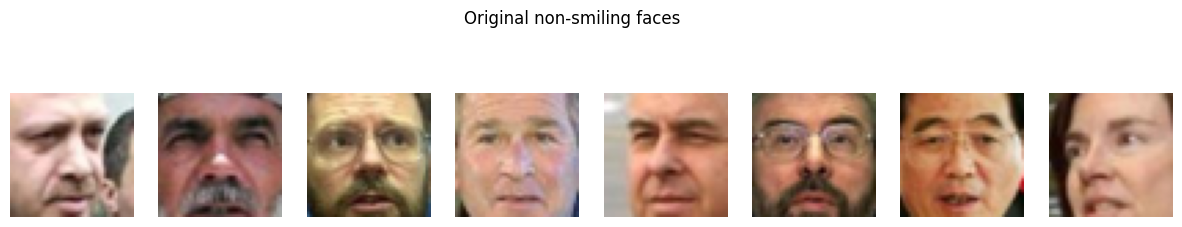

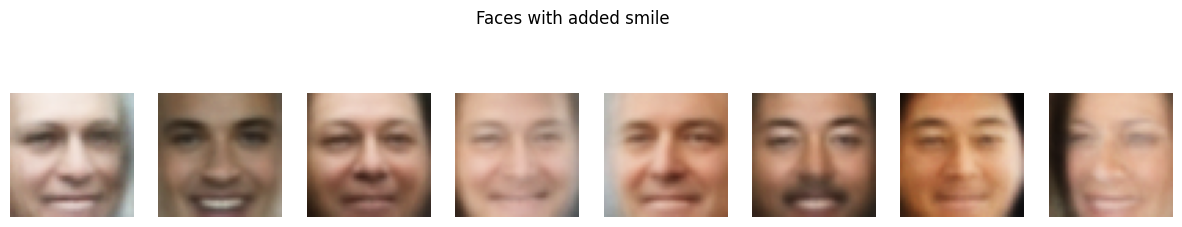

In [87]:
# Возьмем несколько неулыбающихся лиц
test_faces = X_non_smiling[:8].to(device)

autoencoder.eval()

with torch.no_grad():
    reconstruction, latent = autoencoder(test_faces)

    # Коэффициент можно менять: 0.5, 1, 1.5, 2
    alpha = 1.5
    latent_smile = latent + alpha * smile_vector.to(device)

    smiled_faces = autoencoder.decoder(latent_smile)
    smiled_faces = smiled_faces.view(-1, 3, 45, 45)

show_images(test_faces, n=8, title="Original non-smiling faces")
show_images(smiled_faces, n=8, title="Faces with added smile")

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [88]:
from torchvision import datasets, transforms
import torch

batch_size = 32

train_dataset = datasets.MNIST(
    root="./mnist_data/",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.MNIST(
    root="./mnist_data/",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [89]:
latent_dim = 32

In [90]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logsigma = nn.Linear(200, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.view(-1, 1, 28, 28)
        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [91]:
def KL_divergence(mu, logsigma):
    # Формула: -1/2 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl = -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma), dim=1)
    return kl.mean()


def log_likelihood(x, reconstruction):
    # BCE показывает качество восстановления картинки
    bce = F.binary_cross_entropy(reconstruction, x, reduction="sum")
    return bce / x.size(0)


def loss_vae(x, mu, logsigma, reconstruction):
    reconstruction_loss = log_likelihood(x, reconstruction)
    kl_loss = KL_divergence(mu, logsigma)
    return reconstruction_loss + kl_loss

И обучим модель:

In [92]:
criterion = loss_vae

vae = VAE(latent_dim=latent_dim).to(device)

optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

In [93]:
def train_vae(model, train_loader, test_loader, optimizer, epochs=10):
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x = x.to(device)

            optimizer.zero_grad()
            mu, logsigma, reconstruction = model(x)
            loss = loss_vae(x, mu, logsigma, reconstruction)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        test_loss = 0

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                mu, logsigma, reconstruction = model(x)
                loss = loss_vae(x, mu, logsigma, reconstruction)
                test_loss += loss.item() * x.size(0)

        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

        print(f"Epoch {epoch + 1}/{epochs} | train loss: {train_loss:.4f} | test loss: {test_loss:.4f}")

    return train_losses, test_losses


vae_train_losses, vae_test_losses = train_vae(
    vae,
    train_loader,
    test_loader,
    optimizer,
    epochs=10
)

Epoch 1/10 | train loss: 152.8924 | test loss: 119.7412
Epoch 2/10 | train loss: 119.6072 | test loss: 110.0306
Epoch 3/10 | train loss: 113.6800 | test loss: 106.2458
Epoch 4/10 | train loss: 110.1576 | test loss: 104.0986
Epoch 5/10 | train loss: 108.2908 | test loss: 102.6299
Epoch 6/10 | train loss: 107.0676 | test loss: 101.6694
Epoch 7/10 | train loss: 106.1078 | test loss: 100.5681
Epoch 8/10 | train loss: 105.4427 | test loss: 100.6493
Epoch 9/10 | train loss: 104.8685 | test loss: 99.6061
Epoch 10/10 | train loss: 104.4015 | test loss: 99.5700


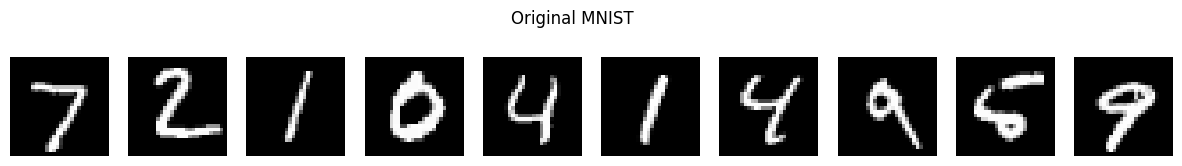

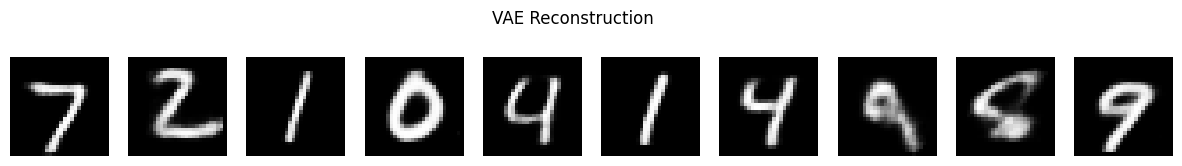

In [94]:
def show_mnist(images, n=10, title=None):
    plt.figure(figsize=(15, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = images[i].detach().cpu().squeeze().numpy()
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()


vae.eval()

with torch.no_grad():
    x, y = next(iter(test_loader))
    x = x.to(device)
    mu, logsigma, reconstruction = vae(x)

show_mnist(x, n=10, title="Original MNIST")
show_mnist(reconstruction, n=10, title="VAE Reconstruction")

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

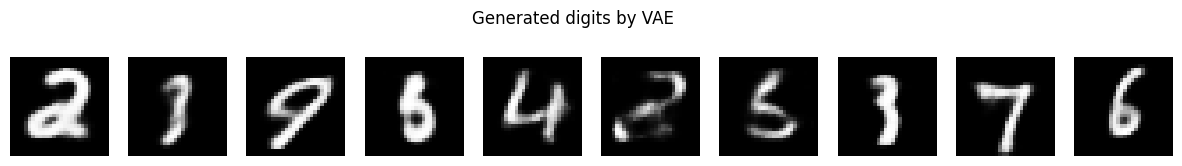

In [95]:
vae.eval()

with torch.no_grad():
    z = torch.randn(10, latent_dim).to(device)
    output = vae.decode(z)

show_mnist(output, n=10, title="Generated digits by VAE")

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

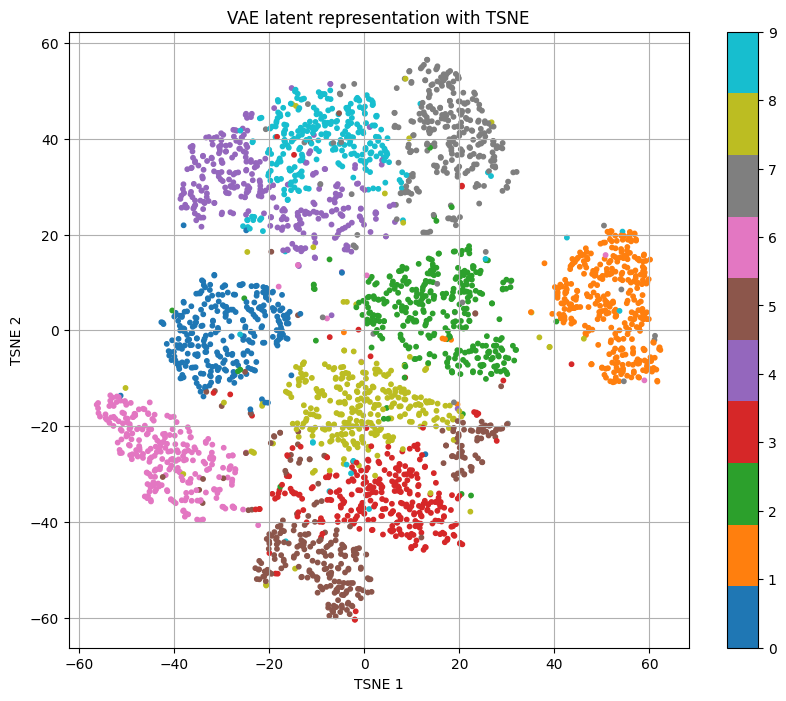

In [96]:
vae.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, logsigma = vae.encode(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Чтобы TSNE работал быстрее, возьмем часть данных
n_points = 3000
idx = np.random.choice(len(all_mu), size=n_points, replace=False)

mu_sample = all_mu[idx]
labels_sample = all_labels[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
mu_2d = tsne.fit_transform(mu_sample)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=labels_sample, cmap="tab10", s=10)
plt.colorbar(scatter)
plt.title("VAE latent representation with TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.grid()
plt.show()

Что вы думаете о виде латентного представления?

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [97]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super().__init__()

        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Encoder получает картинку + one-hot класс
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28 + num_classes, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logsigma = nn.Linear(200, latent_dim)

        # Decoder получает latent vector + one-hot класс
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def one_hot(self, class_num):
        return F.one_hot(class_num, num_classes=self.num_classes).float()

    def encode(self, x, class_num):
        x = x.view(x.size(0), -1)
        y_onehot = self.one_hot(class_num).to(x.device)
        encoder_input = torch.cat([x, y_onehot], dim=1)

        h = self.encoder(encoder_input)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, class_num):
        y_onehot = self.one_hot(class_num).to(z.device)
        decoder_input = torch.cat([z, y_onehot], dim=1)

        reconstruction = self.decoder(decoder_input)
        reconstruction = reconstruction.view(-1, 1, 28, 28)

        return reconstruction

    def forward(self, x, class_num):
        mu, logsigma, class_num = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_num)
        return mu, logsigma, reconstruction

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [98]:
cvae = CVAE(latent_dim=latent_dim, num_classes=10).to(device)
optimizer = torch.optim.Adam(cvae.parameters(), lr=1e-3)
criterion = loss_vae

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [99]:
def train_cvae(model, train_loader, test_loader, optimizer, epochs=10):
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            mu, logsigma, reconstruction = model(x, y)
            loss = loss_vae(x, mu, logsigma, reconstruction)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        test_loss = 0

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                mu, logsigma, reconstruction = model(x, y)
                loss = loss_vae(x, mu, logsigma, reconstruction)
                test_loss += loss.item() * x.size(0)

        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

        print(f"Epoch {epoch + 1}/{epochs} | train loss: {train_loss:.4f} | test loss: {test_loss:.4f}")

    return train_losses, test_losses


cvae_train_losses, cvae_test_losses = train_cvae(
    cvae,
    train_loader,
    test_loader,
    optimizer,
    epochs=10
)

Epoch 1/10 | train loss: 144.6270 | test loss: 114.9101
Epoch 2/10 | train loss: 114.6019 | test loss: 104.9938
Epoch 3/10 | train loss: 108.7891 | test loss: 101.8608
Epoch 4/10 | train loss: 105.9939 | test loss: 100.2677
Epoch 5/10 | train loss: 104.3974 | test loss: 99.7530
Epoch 6/10 | train loss: 103.1511 | test loss: 97.6522
Epoch 7/10 | train loss: 102.2179 | test loss: 97.0012
Epoch 8/10 | train loss: 101.4097 | test loss: 96.4799
Epoch 9/10 | train loss: 100.8845 | test loss: 96.7927
Epoch 10/10 | train loss: 100.2658 | test loss: 96.0771


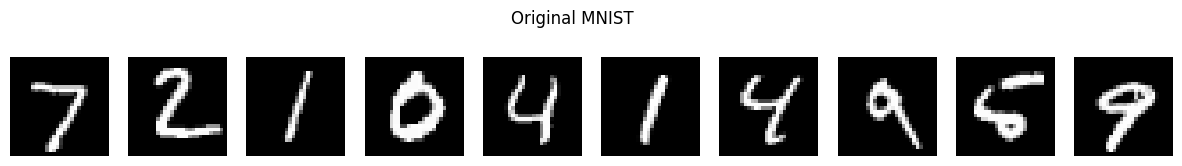

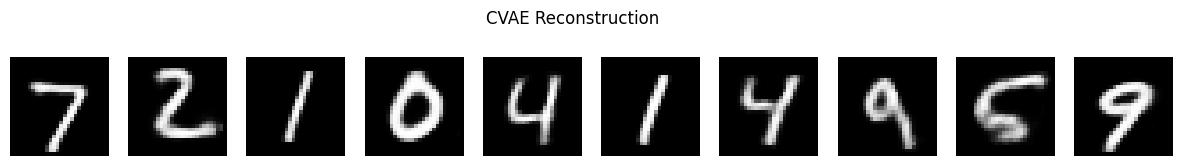

In [100]:
cvae.eval()

with torch.no_grad():
    x, y = next(iter(test_loader))
    x = x.to(device)
    y = y.to(device)

    mu, logsigma, reconstruction = cvae(x, y)

show_mnist(x, n=10, title="Original MNIST")
show_mnist(reconstruction, n=10, title="CVAE Reconstruction")

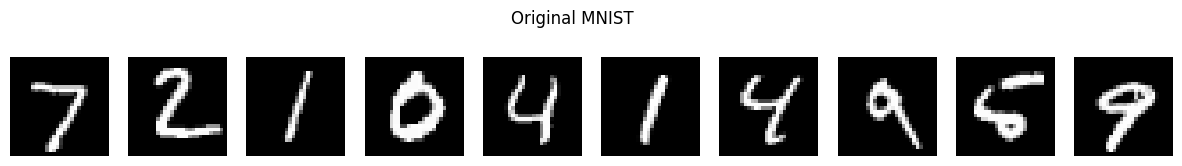

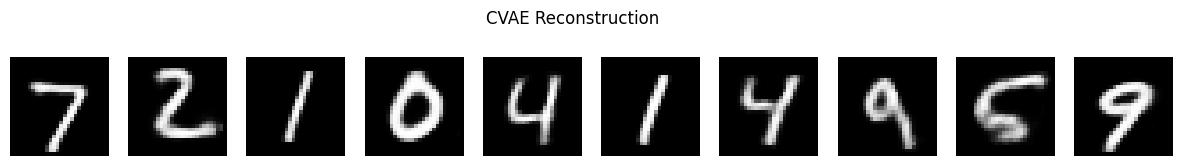

In [101]:
cvae.eval()

with torch.no_grad():
    x, y = next(iter(test_loader))
    x = x.to(device)
    y = y.to(device)

    mu, logsigma, reconstruction = cvae(x, y)

show_mnist(x, n=10, title="Original MNIST")
show_mnist(reconstruction, n=10, title="CVAE Reconstruction")

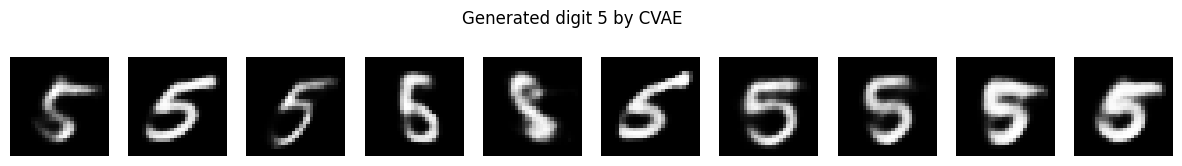

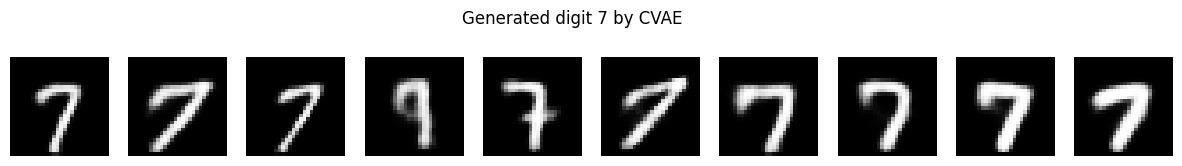

In [102]:
cvae.eval()

with torch.no_grad():
    z = torch.randn(10, latent_dim).to(device)

    labels_5 = torch.full((10,), 5, dtype=torch.long).to(device)
    labels_7 = torch.full((10,), 7, dtype=torch.long).to(device)

    generated_5 = cvae.decode(z, labels_5)
    generated_7 = cvae.decode(z, labels_7)

show_mnist(generated_5, n=10, title="Generated digit 5 by CVAE")
show_mnist(generated_7, n=10, title="Generated digit 7 by CVAE")

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Conditional VAE позволяет управлять генерацией. В отличие от обычного VAE, мы передаем декодеру не только случайный latent-вектор, но и номер нужного класса. Поэтому один и тот же latent-вектор можно использовать для генерации разных цифр, например 5 и 7. Класс задает, какую именно цифру должна нарисовать модель.


# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [103]:
noise_factor = 0.5

X_train_noisy = X_train_t + noise_factor * torch.randn_like(X_train_t)
X_val_noisy = X_val_t + noise_factor * torch.randn_like(X_val_t)

X_train_noisy = torch.clamp(X_train_noisy, 0., 1.)
X_val_noisy = torch.clamp(X_val_noisy, 0., 1.)

denoise_train_loader = DataLoader(
    TensorDataset(X_train_noisy, X_train_t),
    batch_size=64,
    shuffle=True
)

denoise_val_loader = DataLoader(
    TensorDataset(X_val_noisy, X_val_t),
    batch_size=64,
    shuffle=False
)

In [104]:
denoise_autoencoder = Autoencoder(dim_code=dim_code).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(denoise_autoencoder.parameters(), lr=1e-3)

In [60]:
def train_denoising_autoencoder(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x_noisy, x_clean in train_loader:
            x_noisy = x_noisy.to(device)
            x_clean = x_clean.to(device)

            optimizer.zero_grad()
            reconstruction, latent_code = model(x_noisy)
            loss = criterion(reconstruction, x_clean)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_noisy.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x_noisy, x_clean in val_loader:
                x_noisy = x_noisy.to(device)
                x_clean = x_clean.to(device)

                reconstruction, latent_code = model(x_noisy)
                loss = criterion(reconstruction, x_clean)

                val_loss += loss.item() * x_noisy.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch + 1}/{epochs} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    return train_losses, val_losses


denoise_train_losses, denoise_val_losses = train_denoising_autoencoder(
    denoise_autoencoder,
    denoise_train_loader,
    denoise_val_loader,
    criterion,
    optimizer,
    epochs=20
)

Epoch 1/20 | train loss: 0.026091 | val loss: 0.021146
Epoch 2/20 | train loss: 0.018329 | val loss: 0.017206
Epoch 3/20 | train loss: 0.014300 | val loss: 0.014478
Epoch 4/20 | train loss: 0.012691 | val loss: 0.012614
Epoch 5/20 | train loss: 0.012175 | val loss: 0.012210
Epoch 6/20 | train loss: 0.011808 | val loss: 0.012588
Epoch 7/20 | train loss: 0.011284 | val loss: 0.011450
Epoch 8/20 | train loss: 0.010986 | val loss: 0.010960
Epoch 9/20 | train loss: 0.010517 | val loss: 0.010833
Epoch 10/20 | train loss: 0.010187 | val loss: 0.010791
Epoch 11/20 | train loss: 0.009840 | val loss: 0.010281
Epoch 12/20 | train loss: 0.009426 | val loss: 0.009797
Epoch 13/20 | train loss: 0.009158 | val loss: 0.009755
Epoch 14/20 | train loss: 0.008991 | val loss: 0.009712
Epoch 15/20 | train loss: 0.008889 | val loss: 0.009581
Epoch 16/20 | train loss: 0.008625 | val loss: 0.009460
Epoch 17/20 | train loss: 0.008457 | val loss: 0.009342
Epoch 18/20 | train loss: 0.008295 | val loss: 0.009175
E

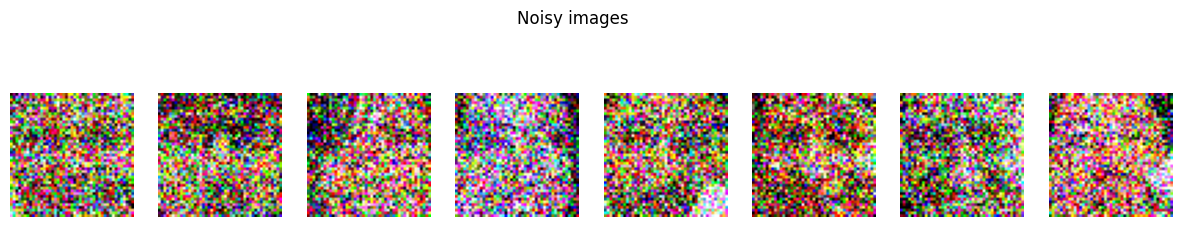

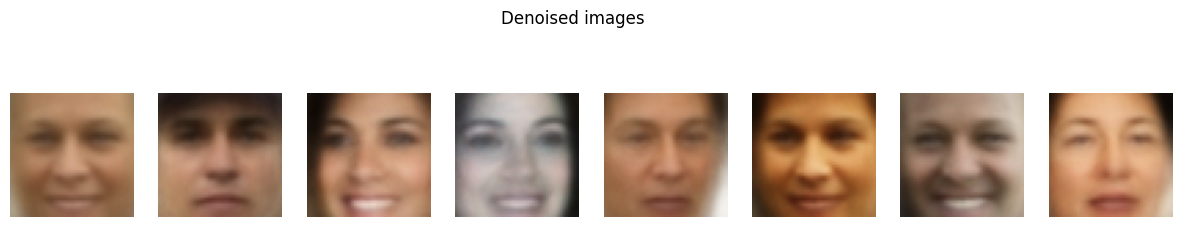

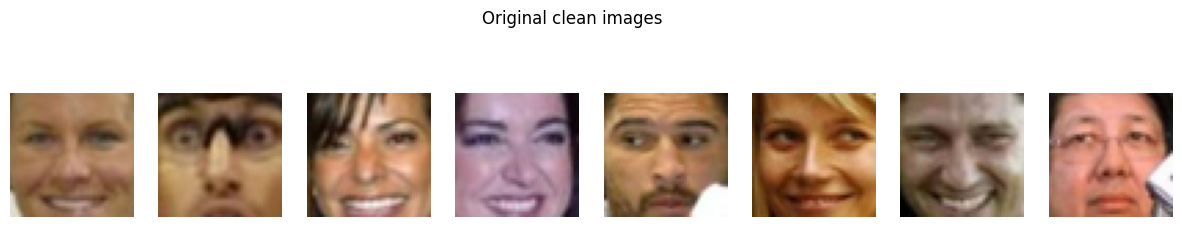

In [61]:
denoise_autoencoder.eval()

with torch.no_grad():
    x_noisy, x_clean = next(iter(denoise_val_loader))
    x_noisy = x_noisy.to(device)
    x_clean = x_clean.to(device)

    reconstruction, latent_code = denoise_autoencoder(x_noisy)

show_images(x_noisy[:8], n=8, title="Noisy images")
show_images(reconstruction[:8], n=8, title="Denoised images")
show_images(x_clean[:8], n=8, title="Original clean images")

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [62]:
codes = get_latent_codes(autoencoder, X_train_t)
codes_np = codes.numpy()

print(codes_np.shape)

(10514, 128)


In [105]:
from sklearn.neighbors import NearestNeighbors

codes = get_latent_codes(autoencoder, X_train_t)
codes_np = codes.numpy()

nn_search = NearestNeighbors(n_neighbors=11, metric="euclidean")
nn_search.fit(codes_np)

print(codes_np.shape)

(10514, 128)


In [ ]:
def get_similar(image, n_neighbors=5):
    autoencoder.eval()

    if image.ndim == 3:
        image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():
        _, code = autoencoder(image)

    code = code.cpu().numpy()

    distances, idx = nn_search.kneighbors(code, n_neighbors=n_neighbors)

    return distances, X_train_t[idx[0]]

In [ ]:
def show_similar(image):
    distances, neighbors = get_similar(image, n_neighbors=11)

    plt.figure(figsize=(18, 6))

    plt.subplot(3, 4, 1)
    img = image.detach().cpu()
    if img.ndim == 4:
        img = img[0]
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title("Original image")
    plt.axis("off")

    for i in range(11):
        plt.subplot(3, 4, i + 2)
        plt.imshow(neighbors[i].cpu().numpy().transpose(1, 2, 0))
        plt.title(f"Dist={distances[0][i]:.3f}")
        plt.axis("off")

    plt.show()

In [ ]:
test_image = X_val_t[0]
show_similar(test_image)

In [ ]:
for i in range(3):
    show_similar(X_val_t[i])